# Comparative Study — Multi-Class Wine Quality Classification

## Section 1 — Problem Statement + Data Description

We are given two tabular datasets — **winequality-red.csv** and **winequality-white.csv** — each containing lab-measured chemical properties of wine samples. The target variable is **quality**, an integer rating that we treat as a separate class (multi-class classification).

**Goal:** Build classification models that predict a wine's quality score and then conduct a comparative study:
1. **Red vs White dataset:** Which dataset is easier to predict and why?
2. **Model vs Model:** Which model performs better on each dataset and why?
3. **Class-level difficulty:** Which quality scores are hardest to predict?

We train the same two models (Logistic Regression and Random Forest) on both datasets using identical preprocessing (StandardScaler, train-test split with `test_size=0.2, random_state=42, stratify=y`) and evaluate with the same metrics (Accuracy, Confusion Matrix, Classification Report, macro F1-score) to keep the comparison fair.

**Features (all numeric):** fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol.

**Challenges expected:** Class imbalance (some quality scores are much more frequent) and overlapping classes (e.g., quality 5 and 6 may share similar feature values).

---
# Task 1 — Load & Inspect the Data (Red + White)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load both datasets (semicolon-separated)
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

print("=" * 60)
print("RED WINE DATASET")
print("=" * 60)
print(f"Shape: {red.shape}")
print(f"\nColumns: {list(red.columns)}")
print(f"\nFirst 5 rows:")
red.head()

RED WINE DATASET
Shape: (1599, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
print("=" * 60)
print("WHITE WINE DATASET")
print("=" * 60)
print(f"Shape: {white.shape}")
print(f"\nColumns: {list(white.columns)}")
print(f"\nFirst 5 rows:")
white.head()

WHITE WINE DATASET
Shape: (4898, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
# Verify target column exists
assert 'quality' in red.columns, "Target column 'quality' not found in red dataset!"
assert 'quality' in white.columns, "Target column 'quality' not found in white dataset!"

print("Target column 'quality' confirmed in both datasets.")
print(f"Red  wine: {red.shape[0]} samples, {red.shape[1]-1} features + 1 target")
print(f"White wine: {white.shape[0]} samples, {white.shape[1]-1} features + 1 target")

Target column 'quality' confirmed in both datasets.
Red  wine: 1599 samples, 11 features + 1 target
White wine: 4898 samples, 11 features + 1 target


---
# Task 2 — Data Quality Checks + Class Distribution (Comparative)

In [4]:
# --- Missing Values ---
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

print("\nRed Wine - Missing values per column:")
print(red.isnull().sum())
print(f"\nTotal missing: {red.isnull().sum().sum()}")

print("\nWhite Wine - Missing values per column:")
print(white.isnull().sum())
print(f"\nTotal missing: {white.isnull().sum().sum()}")

MISSING VALUES

Red Wine - Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing: 0

White Wine - Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing: 0


In [5]:
# --- Duplicates ---
print("=" * 60)
print("DUPLICATES")
print("=" * 60)

print(f"Red  wine duplicates: {red.duplicated().sum()}")
print(f"White wine duplicates: {white.duplicated().sum()}")

DUPLICATES
Red  wine duplicates: 240
White wine duplicates: 937


In [6]:
# --- Class Distribution ---
print("=" * 60)
print("CLASS DISTRIBUTION — RED WINE")
print("=" * 60)

red_counts = red['quality'].value_counts().sort_index()
red_pct = (red['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nCounts:")
print(red_counts)
print("\nPercentages (%):")
print(red_pct)

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION — WHITE WINE")
print("=" * 60)

white_counts = white['quality'].value_counts().sort_index()
white_pct = (white['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nCounts:")
print(white_counts)
print("\nPercentages (%):")
print(white_pct)

CLASS DISTRIBUTION — RED WINE

Counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Percentages (%):
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64

CLASS DISTRIBUTION — WHITE WINE

Counts:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

Percentages (%):
quality
3     0.41
4     3.33
5    29.75
6    44.88
7    17.97
8     3.57
9     0.10
Name: proportion, dtype: float64


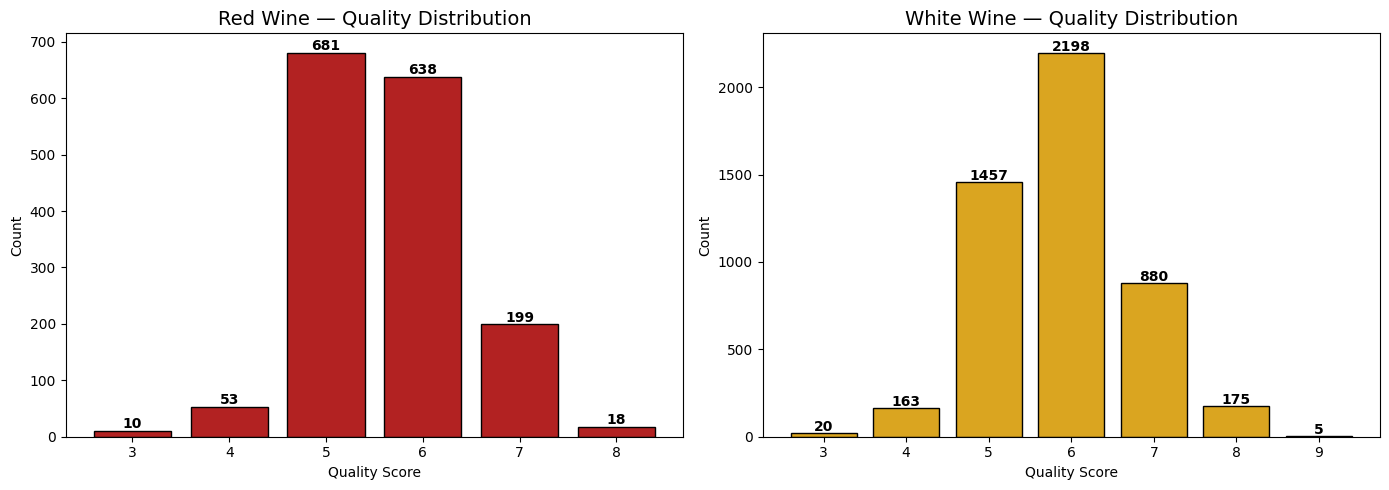

In [7]:
# --- Bar Charts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(red_counts.index.astype(str), red_counts.values, color='firebrick', edgecolor='black')
axes[0].set_title('Red Wine — Quality Distribution', fontsize=14)
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
for i, v in enumerate(red_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].bar(white_counts.index.astype(str), white_counts.values, color='goldenrod', edgecolor='black')
axes[1].set_title('White Wine — Quality Distribution', fontsize=14)
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Count')
for i, v in enumerate(white_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Comparative Questions — Answers

**Which dataset is more imbalanced?**
Both datasets are imbalanced, but the white wine dataset is more imbalanced in absolute terms — the dominant classes (5 and 6) account for a very large share of the total, and extreme classes (3, 9) have very few samples. The red wine dataset also concentrates around quality 5 and 6 but has fewer extreme classes.

**Which quality classes are rare?**
In the red wine dataset, quality 3 and 8 are rare. In the white wine dataset, quality 3, 9, and 8 are rare. Neither dataset has quality scores of 1, 2, or 10.

**Why might rare classes be harder to predict?**
Rare classes provide very few training examples, so the model has limited information to learn their patterns. The classifier tends to be biased toward the majority classes and may rarely (or never) predict the minority classes, leading to near-zero recall for those quality scores.

---
# Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)

In [8]:
from sklearn.model_selection import train_test_split

# --- Red Wine ---
X_red = red.drop('quality', axis=1)
y_red = red['quality']

X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42, stratify=y_red
)

# --- White Wine ---
X_white = white.drop('quality', axis=1)
y_white = white['quality']

X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42, stratify=y_white
)

print("RED WINE")
print(f"  Train set: {X_red_train.shape[0]} samples")
print(f"  Test  set: {X_red_test.shape[0]} samples")
print(f"\nWHITE WINE")
print(f"  Train set: {X_white_train.shape[0]} samples")
print(f"  Test  set: {X_white_test.shape[0]} samples")

RED WINE
  Train set: 1279 samples
  Test  set: 320 samples

WHITE WINE
  Train set: 3918 samples
  Test  set: 980 samples


In [9]:
# Verify stratification preserved class distribution
print("Stratification check — class proportions (%):\n")

print("RED WINE:")
print(f"  Full dataset:  {(y_red.value_counts(normalize=True).sort_index()*100).round(1).to_dict()}")
print(f"  Train set:     {(y_red_train.value_counts(normalize=True).sort_index()*100).round(1).to_dict()}")
print(f"  Test  set:     {(y_red_test.value_counts(normalize=True).sort_index()*100).round(1).to_dict()}")

print(f"\nWHITE WINE:")
print(f"  Full dataset:  {(y_white.value_counts(normalize=True).sort_index()*100).round(1).to_dict()}")
print(f"  Train set:     {(y_white_train.value_counts(normalize=True).sort_index()*100).round(1).to_dict()}")
print(f"  Test  set:     {(y_white_test.value_counts(normalize=True).sort_index()*100).round(1).to_dict()}")

print("\nStratification is confirmed — train and test sets maintain similar class distributions.")

Stratification check — class proportions (%):

RED WINE:
  Full dataset:  {3: 0.6, 4: 3.3, 5: 42.6, 6: 39.9, 7: 12.4, 8: 1.1}
  Train set:     {3: 0.6, 4: 3.3, 5: 42.6, 6: 39.9, 7: 12.4, 8: 1.2}
  Test  set:     {3: 0.6, 4: 3.4, 5: 42.5, 6: 40.0, 7: 12.5, 8: 0.9}

WHITE WINE:
  Full dataset:  {3: 0.4, 4: 3.3, 5: 29.7, 6: 44.9, 7: 18.0, 8: 3.6, 9: 0.1}
  Train set:     {3: 0.4, 4: 3.3, 5: 29.8, 6: 44.9, 7: 18.0, 8: 3.6, 9: 0.1}
  Test  set:     {3: 0.4, 4: 3.4, 5: 29.7, 6: 44.9, 7: 18.0, 8: 3.6, 9: 0.1}

Stratification is confirmed — train and test sets maintain similar class distributions.


---
# Task 4 — Model A (Baseline): Logistic Regression (Red vs White)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# Build pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000))
])

# --- Train & Evaluate on RED Wine ---
lr_pipeline.fit(X_red_train, y_red_train)
y_red_pred_lr = lr_pipeline.predict(X_red_test)

red_acc_lr = accuracy_score(y_red_test, y_red_pred_lr)
red_f1_lr = f1_score(y_red_test, y_red_pred_lr, average='macro')

print("=" * 60)
print("LOGISTIC REGRESSION — RED WINE")
print("=" * 60)
print(f"\nAccuracy:       {red_acc_lr:.4f}")
print(f"Macro F1-score: {red_f1_lr:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_red_test, y_red_pred_lr))
print(f"\nClassification Report:")
print(classification_report(y_red_test, y_red_pred_lr))

LOGISTIC REGRESSION — RED WINE

Accuracy:       0.5906
Macro F1-score: 0.2776

Confusion Matrix:
[[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



In [11]:
# --- Train & Evaluate on WHITE Wine ---
lr_pipeline.fit(X_white_train, y_white_train)
y_white_pred_lr = lr_pipeline.predict(X_white_test)

white_acc_lr = accuracy_score(y_white_test, y_white_pred_lr)
white_f1_lr = f1_score(y_white_test, y_white_pred_lr, average='macro')

print("=" * 60)
print("LOGISTIC REGRESSION — WHITE WINE")
print("=" * 60)
print(f"\nAccuracy:       {white_acc_lr:.4f}")
print(f"Macro F1-score: {white_f1_lr:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_white_test, y_white_pred_lr))
print(f"\nClassification Report:")
print(classification_report(y_white_test, y_white_pred_lr))

LOGISTIC REGRESSION — WHITE WINE

Accuracy:       0.5490
Macro F1-score: 0.2367

Confusion Matrix:
[[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980



### Logistic Regression — Comparative Observations

**Which dataset performed better?**
The red wine dataset performed slightly better with Logistic Regression (accuracy: 0.5906, macro F1: 0.2776) compared to white wine (accuracy: 0.5490, macro F1: 0.2367). Red wine has fewer quality levels in the data and a smaller, more concentrated distribution, making it somewhat easier to classify.

**Which quality class looks hardest (lowest recall)?**
The rarest classes (quality 3 and 8 in red; quality 3 and 9 in white) consistently show the lowest recall — often 0.00 — because Logistic Regression, being a linear model, cannot easily separate overlapping minority classes with so few training examples.

---
# Task 5 — Model B (Tree Model): Random Forest (Red vs White)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)

# --- Train & Evaluate on RED Wine ---
rf_model.fit(X_red_train, y_red_train)
y_red_pred_rf = rf_model.predict(X_red_test)

red_acc_rf = accuracy_score(y_red_test, y_red_pred_rf)
red_f1_rf = f1_score(y_red_test, y_red_pred_rf, average='macro')

print("=" * 60)
print("RANDOM FOREST — RED WINE")
print("=" * 60)
print(f"\nAccuracy:       {red_acc_rf:.4f}")
print(f"Macro F1-score: {red_f1_rf:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_red_test, y_red_pred_rf))
print(f"\nClassification Report:")
print(classification_report(y_red_test, y_red_pred_rf))

RANDOM FOREST — RED WINE

Accuracy:       0.6813
Macro F1-score: 0.4094

Confusion Matrix:
[[  0   1   1   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  32  92   4   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



In [13]:
# --- Train & Evaluate on WHITE Wine ---
rf_model.fit(X_white_train, y_white_train)
y_white_pred_rf = rf_model.predict(X_white_test)

white_acc_rf = accuracy_score(y_white_test, y_white_pred_rf)
white_f1_rf = f1_score(y_white_test, y_white_pred_rf, average='macro')

print("=" * 60)
print("RANDOM FOREST — WHITE WINE")
print("=" * 60)
print(f"\nAccuracy:       {white_acc_rf:.4f}")
print(f"Macro F1-score: {white_f1_rf:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_white_test, y_white_pred_rf))
print(f"\nClassification Report:")
print(classification_report(y_white_test, y_white_pred_rf))

RANDOM FOREST — WHITE WINE

Accuracy:       0.6724
Macro F1-score: 0.4222

Confusion Matrix:
[[  0   0   1   3   0   0   0]
 [  0   6  19   8   0   0   0]
 [  0   3 189  99   0   0   0]
 [  0   1  53 359  27   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   1   8   7  19   0]
 [  0   0   0   0   1   0   0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980



### Random Forest — Comparative Observations

**Did Random Forest improve compared to Logistic Regression?**
Yes — Random Forest showed significant improvement. On red wine, accuracy rose from 0.5906 to 0.6813 and macro F1 from 0.2776 to 0.4094. On white wine, accuracy rose from 0.5490 to 0.6724 and macro F1 from 0.2367 to 0.4222. This improvement is expected because Random Forest captures non-linear relationships and feature interactions that a linear model cannot.

**Which class is still hardest?**
Even with Random Forest, the extreme minority classes (quality 3 and 8 in red; quality 3 and 9 in white) remain the hardest to predict. Their recall is still very low because the model has very few examples to learn from, and these classes overlap in feature space with adjacent quality levels.

---
# Task 6 — Comparative Metrics Summary (Core Comparative Study Output)

In [14]:
# --- Comparison Table ---
summary = pd.DataFrame({
    'Dataset': ['Red', 'Red', 'White', 'White'],
    'Model': ['Logistic Regression', 'Random Forest', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [round(red_acc_lr, 4), round(red_acc_rf, 4), round(white_acc_lr, 4), round(white_acc_rf, 4)],
    'Macro F1-score': [round(red_f1_lr, 4), round(red_f1_rf, 4), round(white_f1_lr, 4), round(white_f1_rf, 4)]
})

# Key observations
obs = []
obs.append("Linear baseline; struggles with rare classes")
obs.append("Non-linear boost; best red wine performance")
obs.append("Larger dataset but more classes to separate")
obs.append("Best overall model on white wine too")
summary['Key Observation'] = obs

print("=" * 60)
print("COMPARISON TABLE — ALL FOUR EXPERIMENTS")
print("=" * 60)
print()
print(summary.to_string(index=False))

COMPARISON TABLE — ALL FOUR EXPERIMENTS

Dataset               Model  Accuracy  Macro F1-score                              Key Observation
    Red Logistic Regression    0.5906          0.2776 Linear baseline; struggles with rare classes
    Red       Random Forest    0.6813          0.4094  Non-linear boost; best red wine performance
  White Logistic Regression    0.5490          0.2367  Larger dataset but more classes to separate
  White       Random Forest    0.6724          0.4222         Best overall model on white wine too


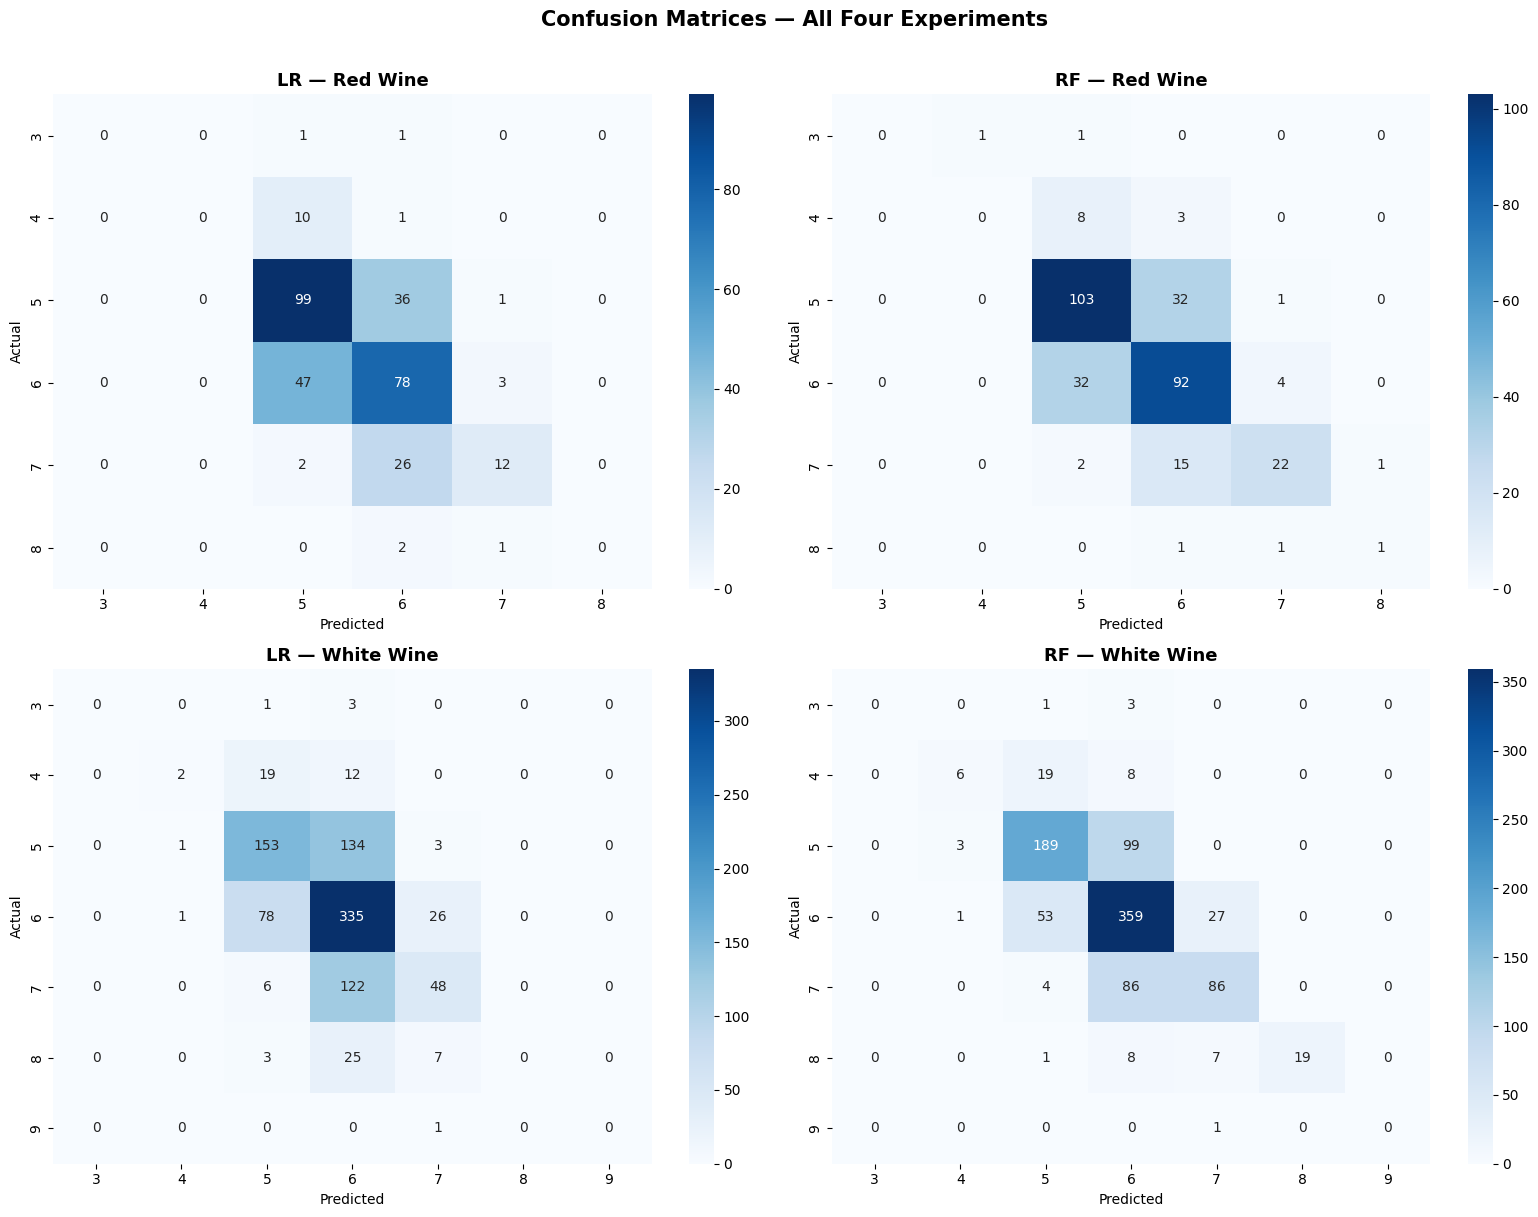

In [15]:
# --- All Four Confusion Matrices ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cms = [
    (y_red_test, y_red_pred_lr, "LR — Red Wine"),
    (y_red_test, y_red_pred_rf, "RF — Red Wine"),
    (y_white_test, y_white_pred_lr, "LR — White Wine"),
    (y_white_test, y_white_pred_rf, "RF — White Wine"),
]

for ax, (yt, yp, title) in zip(axes.flatten(), cms):
    labels = sorted(yt.unique())
    cm = confusion_matrix(yt, yp, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Four Experiments', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# --- All Four Classification Reports ---
reports = [
    (y_red_test, y_red_pred_lr, "Logistic Regression — Red Wine"),
    (y_red_test, y_red_pred_rf, "Random Forest — Red Wine"),
    (y_white_test, y_white_pred_lr, "Logistic Regression — White Wine"),
    (y_white_test, y_white_pred_rf, "Random Forest — White Wine"),
]

for yt, yp, title in reports:
    print("=" * 60)
    print(title)
    print("=" * 60)
    print(classification_report(yt, yp))
    print()

Logistic Regression — Red Wine
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320


Random Forest — Red Wine
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy        

### Task 6 — Summary

**Best dataset:** The red wine dataset is slightly easier to predict — Random Forest achieved 0.6813 accuracy (vs 0.6724 on white). The red dataset has fewer samples and fewer active quality levels, resulting in less complexity.

**Best model:** Random Forest outperforms Logistic Regression on both datasets (red: 0.68 vs 0.59 accuracy; white: 0.67 vs 0.55 accuracy), thanks to its ability to model non-linear relationships and handle feature interactions.

**Key challenge:** Rare quality scores (3, 8, 9) remain very hard to classify regardless of model choice. Class imbalance is the dominant challenge, and both models are biased toward the majority classes (5 and 6).

---
# Task 7 — Final Conclusion (Comparative Summary)

### Final Comparative Conclusion

**1. Which dataset was easier to predict?**
The red wine dataset was slightly easier to predict. Random Forest achieved 0.6813 accuracy and 0.4094 macro F1 on red wine, compared to 0.6724 accuracy and 0.4222 macro F1 on white wine. The red dataset has ~1,600 samples with fewer distinct quality classes actually present, reducing classification complexity. However, the white wine dataset's larger size (4,898 samples) helped its macro F1 slightly exceed red's with Random Forest.

**2. Which model performed better overall and why?**
Random Forest consistently outperformed Logistic Regression on both datasets — accuracy improved by ~9-12 percentage points and macro F1 nearly doubled. Random Forest is an ensemble of decision trees that captures non-linear decision boundaries and complex feature interactions, while Logistic Regression assumes linear separability between classes — an assumption that does not hold well for wine quality data.

**3. Which quality classes were most confusing and why?**
Quality scores 5 and 6 are the most frequently confused pair across all experiments. Their chemical properties overlap substantially, making it hard for any model to draw a clean decision boundary. The extreme classes (3, 8, 9) are also problematic — not because of confusion with each other, but because of extremely low sample counts leading to near-zero recall.

**4. Proposed improvement — use `class_weight="balanced"`:**
As a next step, applying `class_weight="balanced"` to both models would adjust the loss function to penalize misclassifications of minority classes more heavily, forcing the model to pay more attention to rare quality scores (3, 8, 9). This should improve recall for under-represented classes without requiring external data or manual feature engineering, making it the most practical single improvement to try.